In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")


import sys
from pathlib import Path

sys.path.insert(0,'/Users/ayman/Desktop/MSc Project Local/MSc-Project-ZTE')
import aymansigmri as asm

## Notes
- Last attempt did't work due to the nufft adjoint operation presumably causing a loss of information
- As per toby's suggestion - no need to go back and forth through operations
- Therefore proceed as follows:

1. Take the ZTE data from radial to cartesian k-space
2. Make a note of the missing in the centre via a mask
    - This may require some extra work due to kernel smoothing
3. Perform hankel -> SVD and inverse
4. Replace all except inner most region (i.e. that was sampled)



### Currently no way to know exactly where the dead time gap is in cartesian. Needed for few reasons
1. Direct comparision with ground truth data
2. Replacement/data concistency step

In [9]:
width=4
gap = 2

In [10]:
def nufft_gridding(kspace, coords, n_coils, n_x, n_y,width):
    n_samples = kspace.shape[-1]
    dcf = np.sqrt(coords[..., 0]**2 + coords[..., 1]**2)
    imagegrid = sp.nufft_adjoint(kspace * dcf, coords, oshape=(n_coils, n_x, n_y), width=width)
    gridded_data = sp.fft(imagegrid, axes=(-2, -1))
    return gridded_data
zte_radialkspace, zte_radialcoords, radialkspace, radialcoords, mask = asm.generate_zte_data(ksp=ksp, coord=coord, n_missing=gap, undersampling_factor=1)

zte_radial_kspace, zte_radial_coords, full_zte_radial_kspace, full_zte_radial_coords, zte_mask, groundtruth_radial, n_points_full = asm.generate_zte_data_trial(ksp=ksp, coord=coord, n_missing=gap, undersampling_factor=1)

zte_radial_kspacedlt, zte_radial_coordsdlt = asm.generate_zte_data_OLD(ksp=ksp, coord=coord, n_missing=gap, undersampling_factor=1)

cartesian_zte = nufft_gridding(kspace=zte_radial_kspacedlt, coords=zte_radial_coordsdlt, n_coils=12, n_x=256, n_y=256, width=width)




## Zero Padding
- occurs in image space
- __Note__: what happens if we fft then ifft ->> scaling?

In [11]:
dcf = np.sqrt(zte_radial_coordsdlt[..., 0]**2 + zte_radial_coordsdlt[..., 1]**2)
imagegrid = sp.nufft_adjoint(zte_radial_kspacedlt * dcf, zte_radial_coordsdlt, oshape=(12, 256,256))

image_grid_eng = sp.resize(imagegrid, [12,512,512])

cartesian_kspace = sp.fft(imagegrid, axes=(-2, -1)) 

cartesian_kspace_enl = sp.fft(image_grid_eng, axes=(-2, -1))

#pl.ImagePlot(imagegrid,z=0)
#pl.ImagePlot(image_grid_eng, z=0)

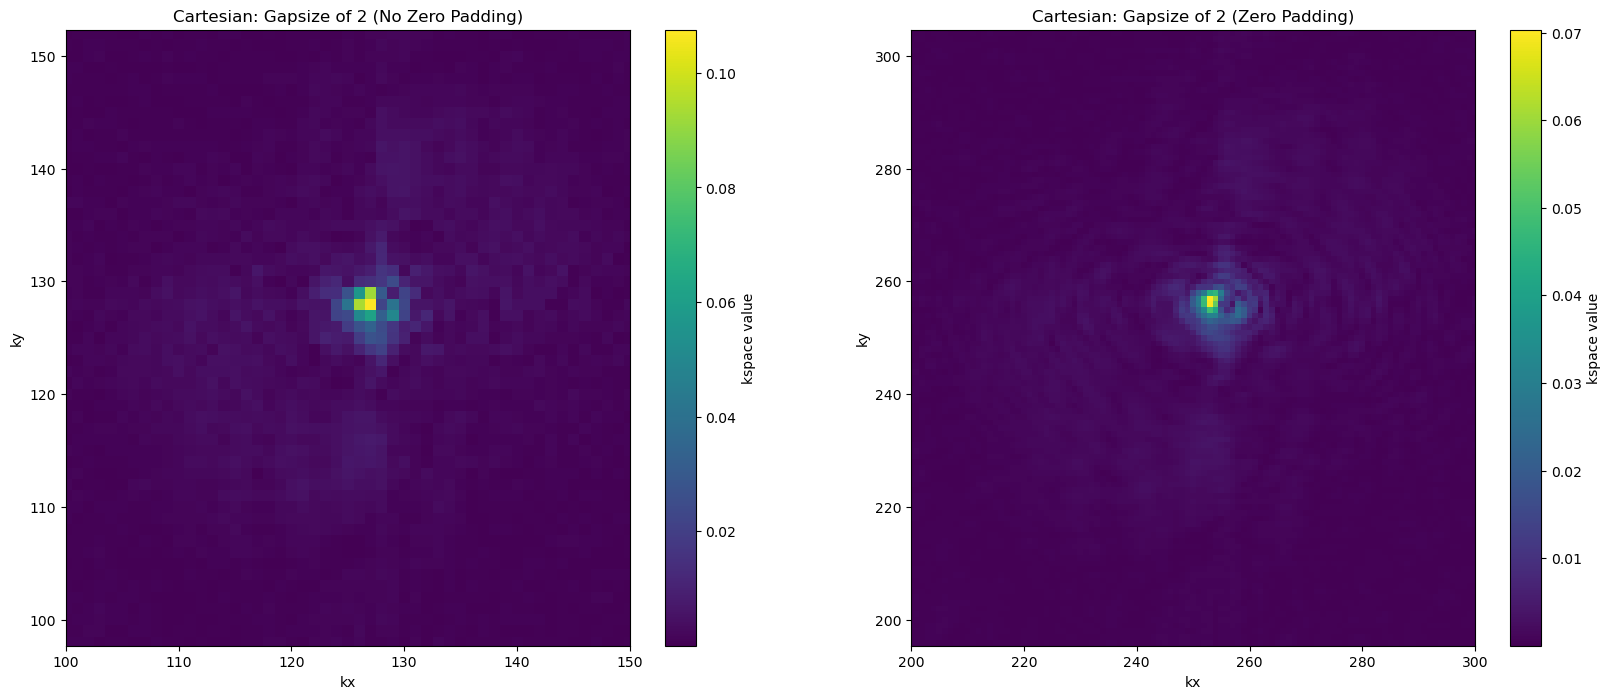

In [12]:
fig, ax = plt.subplots(nrows=1,ncols=2, figsize=(20,8))


im = ax[0].imshow(np.abs(cartesian_zte[0]), cmap='viridis', origin='lower')
fig.colorbar(im, ax=ax[0], label='kspace value')

ax[0].set_title(f'Cartesian: Gapsize of {gap} (No Zero Padding)')
ax[0].set_xlabel('kx')
ax[0].set_ylabel('ky')
ax[0].axis('equal')
ax[0].set_xlim(100,150)
ax[0].set_ylim(100,150)
'''ax[1].grid(visible=True, linewidth=5)
ax[1].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1].yaxis.set_major_locator(plt.MultipleLocator(1))'''


im = ax[1].imshow(np.abs(cartesian_kspace_enl[0]), cmap='viridis', origin='lower')
fig.colorbar(im, ax=ax[1], label='kspace value')

ax[1].set_title(f'Cartesian: Gapsize of {gap} (Zero Padding)')
ax[1].set_xlabel('kx')
ax[1].set_ylabel('ky')
ax[1].axis('equal')
ax[1].set_xlim(200,300)
ax[1].set_ylim(200,300)
'''ax[1].grid(visible=True, linewidth=5)
ax[1].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1].yaxis.set_major_locator(plt.MultipleLocator(1))'''
plt.show()

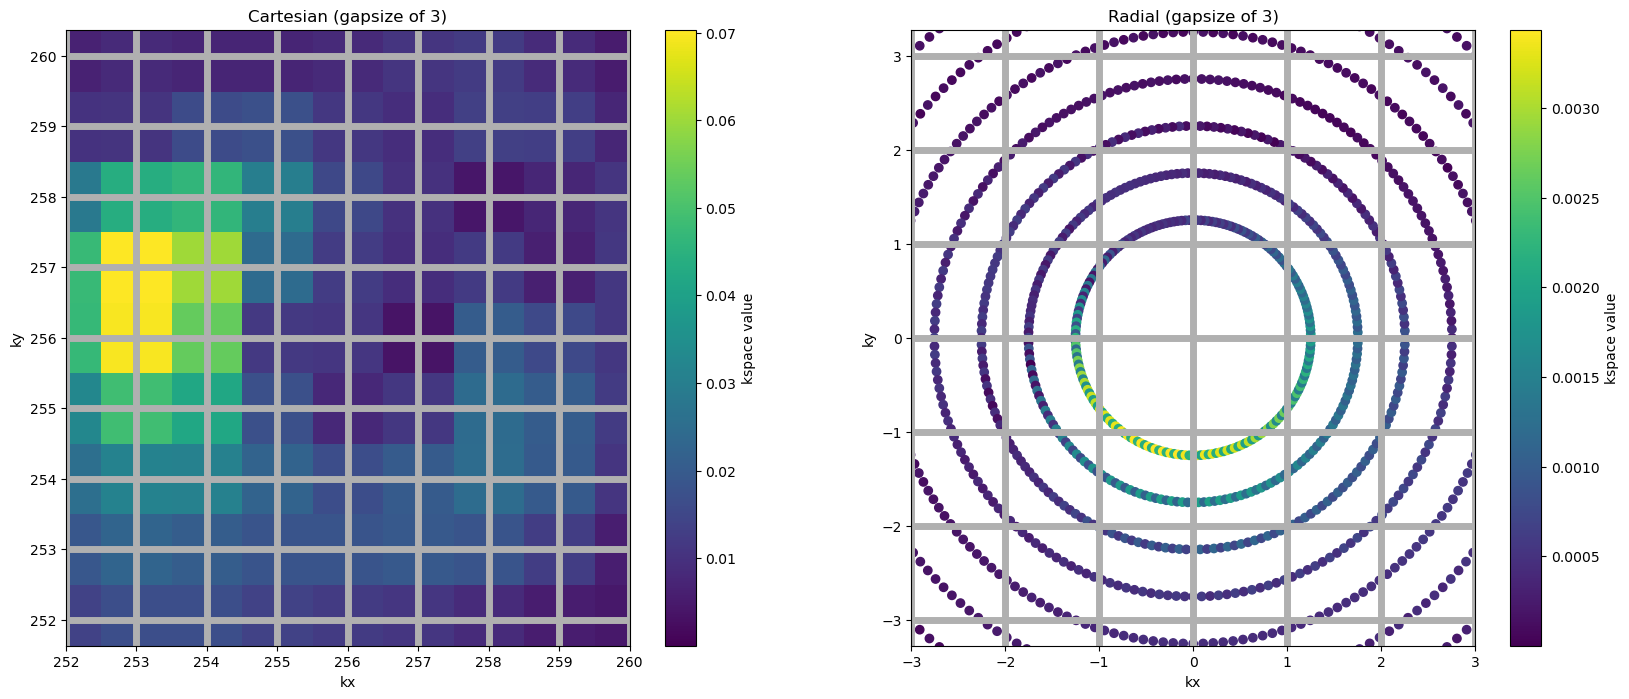

In [13]:
all_coords = zte_radial_coordsdlt.reshape(-1, 2)

fig, ax = plt.subplots(nrows=1,ncols=2, figsize=(20,8))


im = ax[0].imshow(np.abs(cartesian_kspace_enl[0]), cmap='viridis', origin='lower')
fig.colorbar(im, ax=ax[0], label='kspace value')

ax[0].set_title('Cartesian (gapsize of 3)')
ax[0].set_xlabel('kx')
ax[0].set_ylabel('ky')
ax[0].axis('equal')
ax[0].set_xlim(512/2 - 4,512/2 + 4)
ax[0].set_ylim(512/2 - 4,512/2 + 4)
ax[0].grid(visible=True, linewidth=5)
ax[0].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[0].yaxis.set_major_locator(plt.MultipleLocator(1))


im1 = ax[1].scatter(all_coords[:, 1], all_coords[:, 0], c=np.abs(zte_radial_kspacedlt[1]), cmap='viridis')
#im1 = ax[1].imshow(np.abs(zte_radialkspace[1]), cmap='viridis', origin='lower')
fig.colorbar(im1, ax=ax[1], label='kspace value')
ax[1].set_title('Radial (gapsize of 3)')
ax[1].set_xlabel('kx')
ax[1].set_ylabel('ky')
ax[1].axis('equal')
ax[1].grid(visible=True, linewidth=5)
ax[1].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1].yaxis.set_major_locator(plt.MultipleLocator(1))

ax[1].set_xlim(0 - 3,0 + 3)
ax[1].set_ylim(0 - 3,0 + 3)
plt.show()

## Trying to build the mask
- Want this to generalise for more than one instance
- Struggling to get this right at the moment

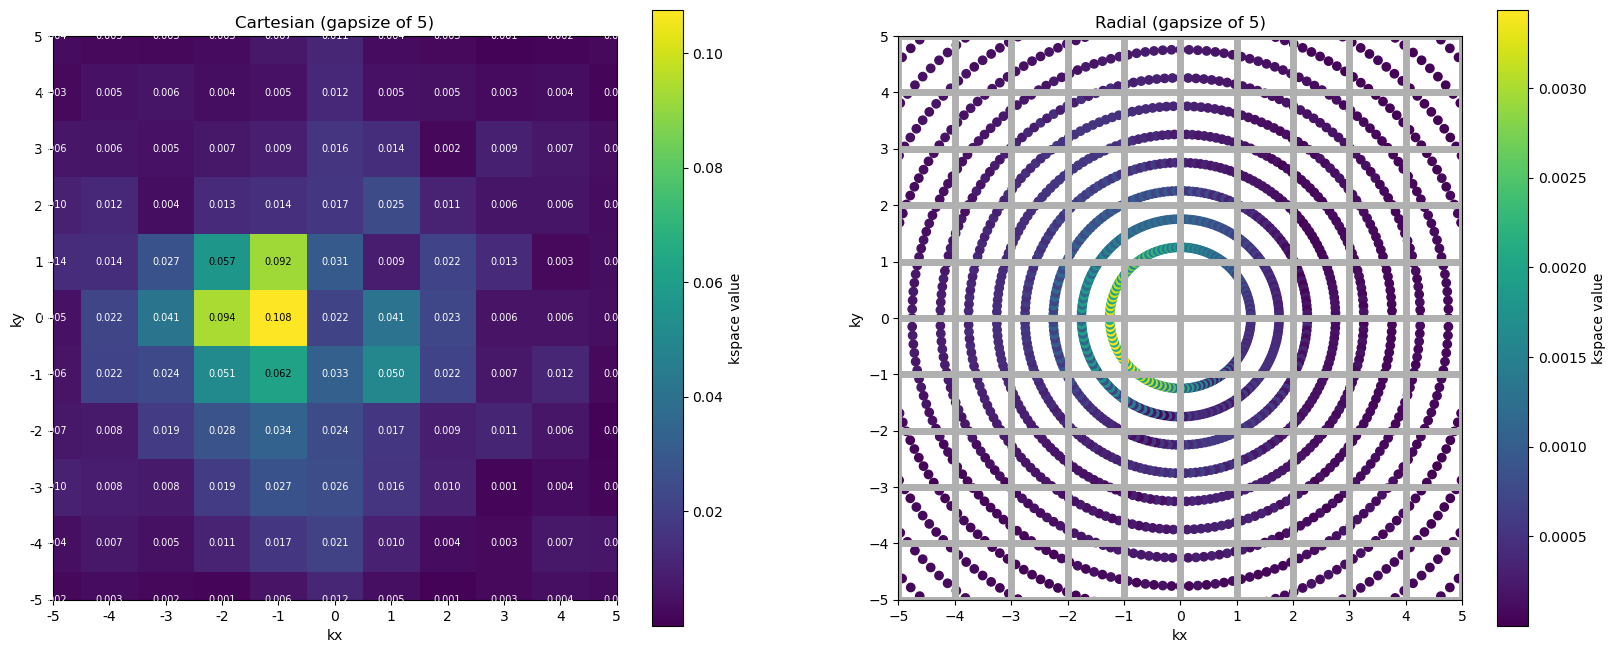

In [16]:
N = cartesian_zte.shape[-1]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))

im = ax[0].imshow(np.abs(cartesian_zte[0]), cmap='viridis', origin='lower')
fig.colorbar(im, ax=ax[0], label='kspace value')

ax[0].set_title('Cartesian (gapsize of 5)')
ax[0].set_xlabel('kx')
ax[0].set_ylabel('ky')
ax[0].set_xlim(N//2 - 5, N//2 + 5)
ax[0].set_ylim(N//2 - 5, N//2 + 5)
ax[0].set_aspect('equal')

tick_pixels = np.arange(N//2 - 5, N//2 + 6)
tick_labels = tick_pixels - N//2

ax[0].set_xticks(tick_pixels)
ax[0].set_xticklabels(tick_labels)
ax[0].set_yticks(tick_pixels)
ax[0].set_yticklabels(tick_labels)

vmax = np.abs(cartesian_zte[0]).max()
for iy in range(N//2 - 5, N//2 + 6):
    for ix in range(N//2 - 5, N//2 + 6):
        val = np.abs(cartesian_zte[0, iy, ix])
        color = 'black' if val > vmax / 2 else 'white'
        ax[0].text(ix, iy, f'{val:.3f}', ha='center', va='center', fontsize=7, color=color)

im1 = ax[1].scatter(all_coords[:, 0], all_coords[:, 1], c=np.abs(zte_radial_kspacedlt[1]), cmap='viridis')
fig.colorbar(im1, ax=ax[1], label='kspace value')
ax[1].set_title('Radial (gapsize of 5)')
ax[1].set_xlabel('kx')
ax[1].set_ylabel('ky')
ax[1].set_aspect('equal')
ax[1].set_xlim(-5, 5)
ax[1].set_ylim(-5, 5)
ax[1].grid(visible=True, linewidth=5)
ax[1].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1].yaxis.set_major_locator(plt.MultipleLocator(1))

plt.show()

# Next Steps
- Test with different gap sizes and 'spoke legnths'
    - Consider how to do this now we are no longer usings spokes
- Build full analysis pipeline to compare optimal amount of information to put into the process via l2 norm minimisation

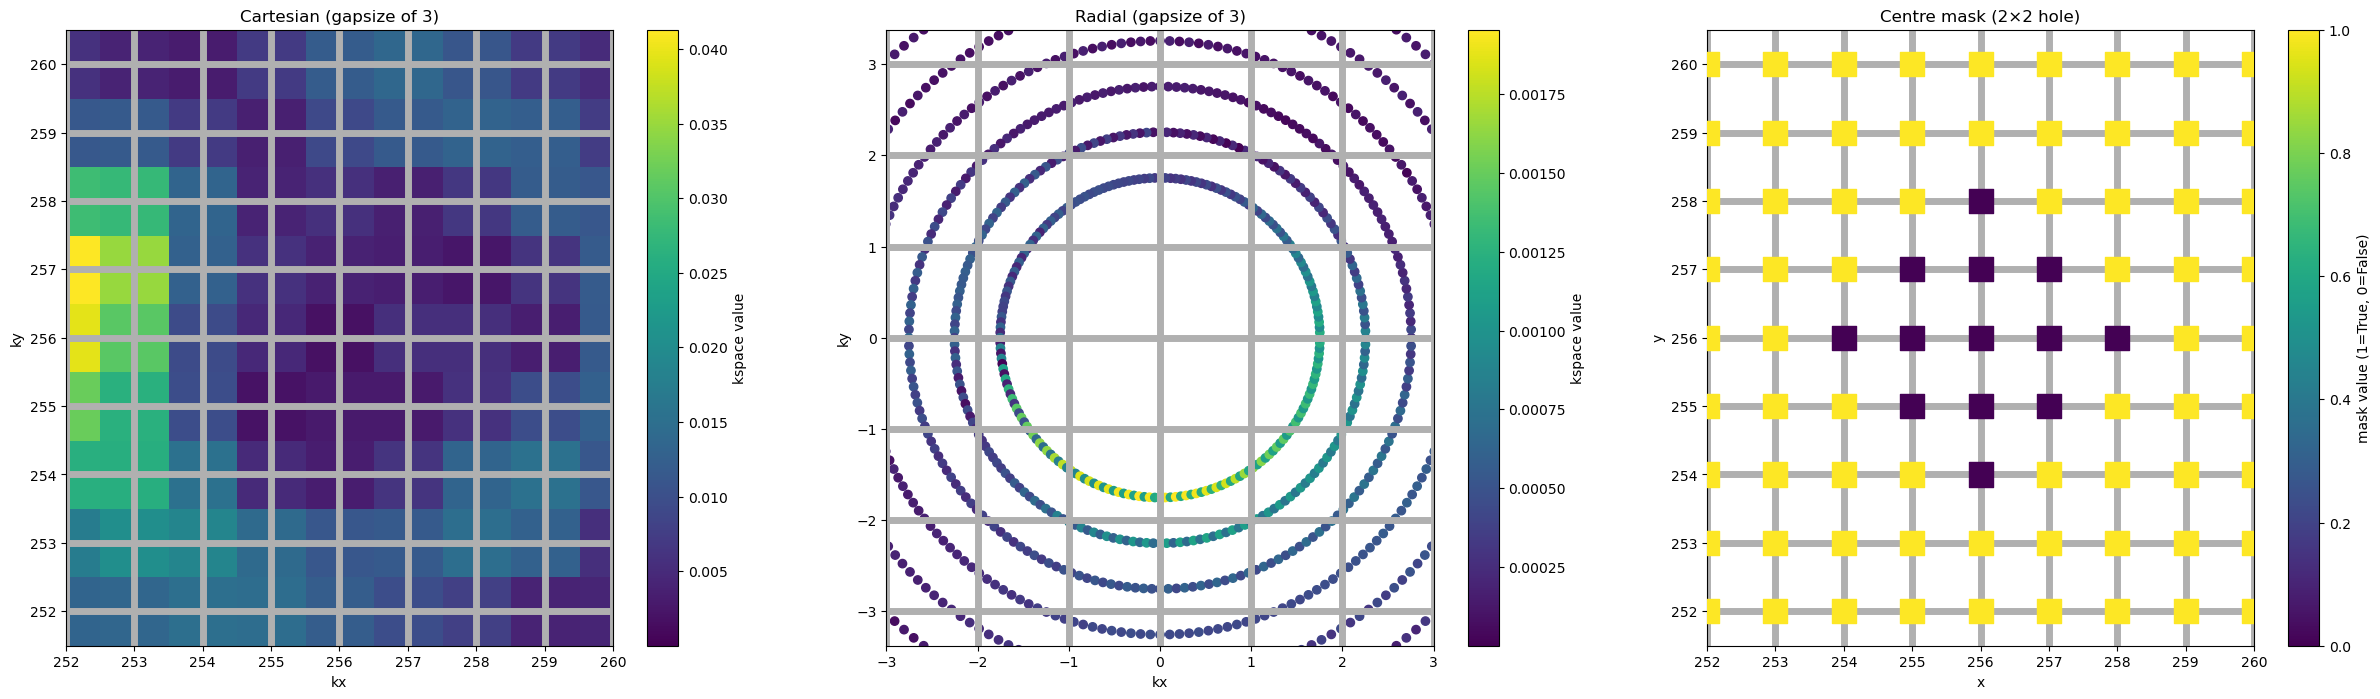

In [8]:
cart_x, cart_y = cartesian_kspace_enl.shape[1], cartesian_kspace_enl.shape[2]

mask = np.ones((cart_x, cart_y), dtype=int)
mask[254:259, 256] = 0
mask[256, 254:259] = 0
mask[255:258, 255:258] = 0

all_coords = zte_radial_coordsdlt.reshape(-1, 2)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 8))


im = ax[0].imshow(np.abs(cartesian_kspace_enl[0]), cmap='viridis', origin='lower')
fig.colorbar(im, ax=ax[0], label='kspace value')

ax[0].set_title('Cartesian (gapsize of 3)')
ax[0].set_xlabel('kx')
ax[0].set_ylabel('ky')
ax[0].axis('equal')
ax[0].set_xlim(512/2 - 4,512/2 + 4)
ax[0].set_ylim(512/2 - 4,512/2 + 4)
ax[0].grid(visible=True, linewidth=5)
ax[0].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[0].yaxis.set_major_locator(plt.MultipleLocator(1))


im1 = ax[1].scatter(all_coords[:, 1], all_coords[:, 0], c=np.abs(zte_radial_kspacedlt[1]), cmap='viridis')
fig.colorbar(im1, ax=ax[1], label='kspace value')
ax[1].set_title('Radial (gapsize of 3)')
ax[1].set_xlabel('kx')
ax[1].set_ylabel('ky')
ax[1].axis('equal')
ax[1].grid(visible=True, linewidth=5)
ax[1].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1].yaxis.set_major_locator(plt.MultipleLocator(1))
ax[1].set_xlim(0 - 3, 0 + 3)
ax[1].set_ylim(0 - 3, 0 + 3)



yy, xx = np.mgrid[0:cart_x, 0:cart_y]
im2 = ax[2].scatter(xx.ravel(), yy.ravel(), c=mask.ravel().astype(int), cmap='viridis', s=300, marker='s', zorder=3)
fig.colorbar(im2, ax=ax[2], label='mask value (1=True, 0=False)')
ax[2].set_title('Centre mask (2×2 hole)')
ax[2].set_xlabel('x')
ax[2].set_ylabel('y')
ax[2].axis('equal')
ax[2].set_xlim(512/2 - 4,512/2 + 4)
ax[2].set_ylim(512/2 - 4,512/2 + 4)
ax[2].grid(visible=True, linewidth=5)
ax[2].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[2].yaxis.set_major_locator(plt.MultipleLocator(1))

plt.show()

In [9]:
sp.ifft(cartesian_kspace_enl)

array([[[-6.91602042e-20+3.94093198e-20j,
         -2.92351057e-20-3.77473659e-21j,
          1.81592338e-20+3.33575154e-20j, ...,
         -2.27592165e-20+4.53426861e-20j,
         -1.42706438e-19-2.75655106e-21j,
         -5.38320228e-20+9.12737421e-21j],
        [-3.98315538e-20-5.38020637e-21j,
         -3.83714220e-20-6.65905676e-20j,
          9.81176105e-20-4.21881243e-20j, ...,
          7.48707761e-20-2.02451270e-20j,
         -7.57183372e-20-6.36714051e-20j,
         -4.43819436e-20-1.22059003e-20j],
        [-9.97135163e-21+2.82938397e-20j,
         -3.62826807e-20-2.98569150e-20j,
          8.97750378e-20-3.56386336e-20j, ...,
          5.85938652e-20-5.11083936e-20j,
         -7.56689954e-20+2.97020941e-20j,
         -2.14289840e-20+5.88530987e-20j],
        ...,
        [ 2.93527597e-21-6.01555876e-20j,
          1.16390730e-20-6.37636070e-20j,
          5.30786282e-20-1.05288879e-19j, ...,
          2.26072153e-20-6.65912234e-20j,
         -4.01490580e-20-2.79773038e-20j

In [10]:
def cartesian_data_consistency(kspace_cartsvd, kspace_cartacquired, halfmask_width):
    size = kspace_cartsvd[0,0].shape[1]
    cart_mask = np.ones((size, size),dtype=bool)
    
    cen_x, cen_y = size // 2, size // 2
    cart_mask[cen_x - halfmask_width:cen_x + halfmask_width, cen_y - halfmask_width: cen_y + halfmask_width] = False

    cartesian_kspace_consistent = kspace_cartsvd.copy()

    for coil in range(kspace_cartsvd.shape[1]):
        cartesian_kspace_consistent[coil][cart_mask] = kspace_cartacquired[coil][cart_mask]

    return cartesian_kspace_consistent, cart_mask

def im_recon_cart(kspace, save_path=None):
    grid_recon = sp.ifft(kspace)
    im_rss_recon = np.sum(np.abs(grid_recon)**2, axis=0)**0.5
    fig = pl.ImagePlot(im_rss_recon)
    if save_path:
        fig.savefig(save_path)

In [11]:
import numpy as np
arr = np.array(([2,2,2,2,2,2],[2,2,2,2,2,2],[2,2,2,2,2,2]))
arr_mask = np.ones(arr.shape, dtype=int)
arr_mask[:,1:3]=False

arr_mask

array([[1, 0, 0, 1, 1, 1],
       [1, 0, 0, 1, 1, 1],
       [1, 0, 0, 1, 1, 1]])

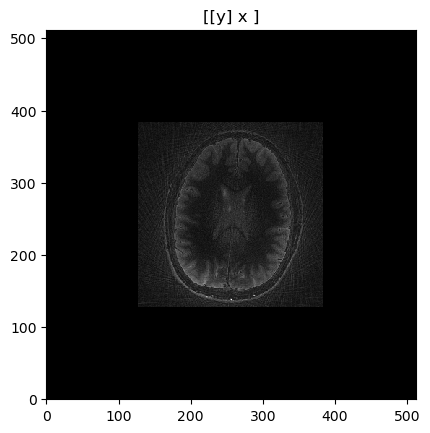

In [ ]:
cartesian_zte = cartesian_kspace_enl

cart_x, cart_y = cartesian_zte.shape[1], cartesian_zte.shape[2]

mask = np.ones((cart_x, cart_y), dtype=int)
mask[254:259, 256] = 0
mask[256, 254:259] = 0
mask[255:258, 255:258] = 0

win = 5

n_iters = 5
iter_count = 0
asm.im_recon_cart(kspace=cartesian_zte)
while iter_count < n_iters:
    
    hankel_matrix, n_coils, Numx, Numy = asm.hankel(kspace=cartesian_zte, w=win)

    U, S_reduced, Vh = asm.sig_val_thresholding(data=hankel_matrix, zero_thresh=0.2)
    data_recon = (U * S_reduced) @ Vh

    kspace_cart_coils_recon = asm.hankel_H(data_recon, n_coils=cartesian_zte.shape[1], Nx=cartesian_zte.shape[1], Ny=cartesian_zte.shape[2], w=win)

    kspace_cart_coils_consistent = kspace_cart_coils_recon

    for coil in range(cartesian_zte.shape[1]):
        kspace_cart_coils_consistent[coil][mask] = cartesian_zte[coil][mask]

    iter_count += 1
    grid_recon = sp.ifft(kspace_cart_coils_consistent)
    im_rss_recon = np.sum(np.abs(grid_recon)**2, axis=0)**0.5
    pl.ImagePlot(im_rss_recon)
    cartesian_zte = kspace_cart_coils_consistent